# Sentiment Timeline Analysis

This notebook is for analyzing the changes in student sentiment for course difficulty and quality over time, and seeing if these changes align with major LLM release dates.

The dataset used for this will be the rate-my-professors review dataset, scraped from rate my professors website

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
project_root = next(path for path in [cwd, *cwd.parents] if (path / "src").exists())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.sentiment import (
    count_department_release_behaviors,
    load_releases,
    major_departments,
    overlay_releases,
    plot_department_ratings,
    plot_overall_ratings,
    plot_release_period_ratings,
    plot_smoothed_ratings,
    prepare_course_analysis,
    prepare_department_analysis,
    prepare_overall_analysis,
    prepare_review_dataset,
    summarize_department_ratings,
    summarize_department_release_behaviors,
    summarize_release_period_ratings,
)


In [2]:
reviews_path = project_root / "data" / "rmp_ucsd_reviews.csv"
releases_path = project_root / "data" / "chatgpt_model_updates.csv"

analysis_start = pd.Timestamp("2016-01-01")
analysis_end = pd.Timestamp("2026-12-31")
classification_start = pd.Timestamp("2024-01-01")
classification_end = pd.Timestamp("2025-12-31")
selected_course = "PHYS2A"
course_list = ["MATH20C", "PHYS2A", "CHEM6A", "ECE35", "ECE45", "HUM3", "MMW11"]

reviews_df = prepare_review_dataset(reviews_path)
releases_df = load_releases(releases_path)


## Department Summary

In [3]:
department_summary = summarize_department_ratings(reviews_df)
display(department_summary.round(3))


,department,quality_mean,quality_count,difficulty_mean,difficulty_count,review_count
0,MAT,3.474,2505,3.332,2505,2505
1,CHE,3.273,1405,3.679,1405,1405
2,PSY,4.158,1079,2.957,1079,1079
3,CSE,3.277,1071,3.459,1071,1071
4,PHY,3.313,840,3.485,840,840
...,...,...,...,...,...,...
185,HEM,1.000,1,5.000,1,1
186,MFI,1.000,1,5.000,1,1
187,ODD,1.000,1,4.000,1,1
188,PCY,1.000,1,3.000,1,1


## Department Trends

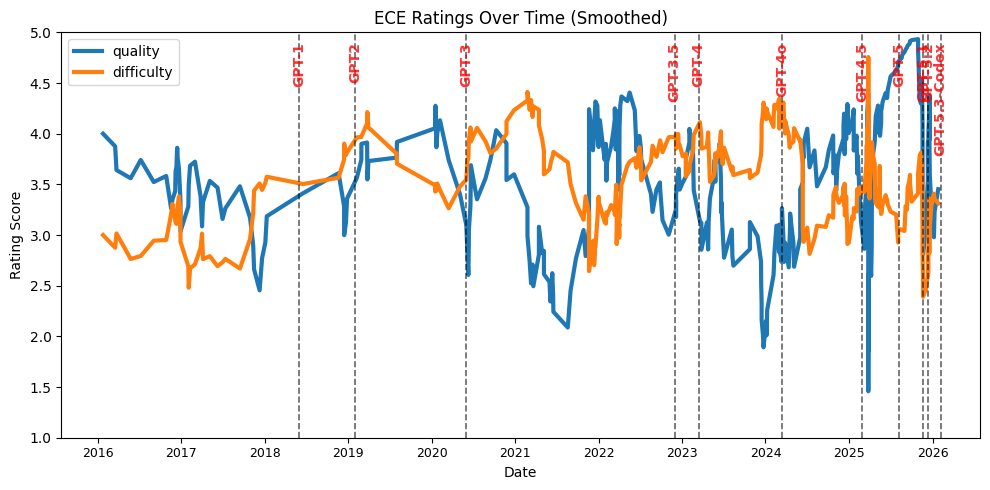

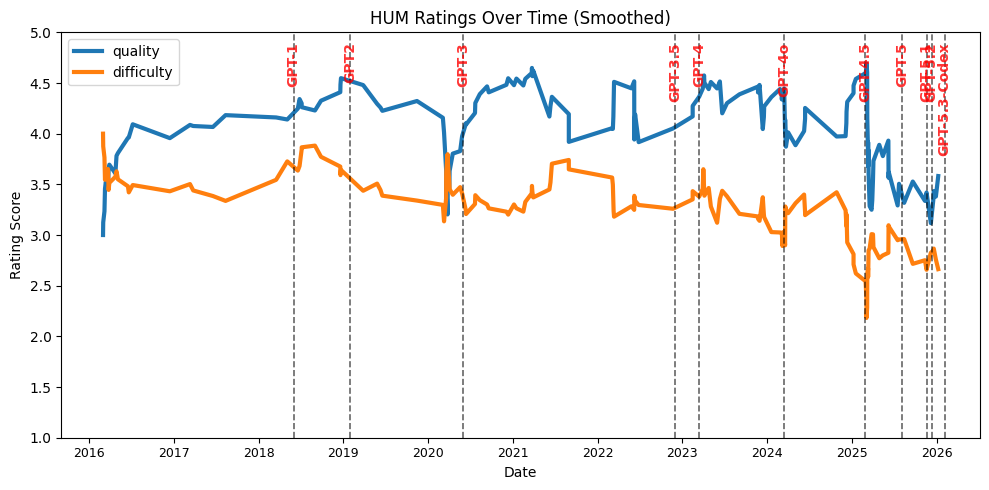

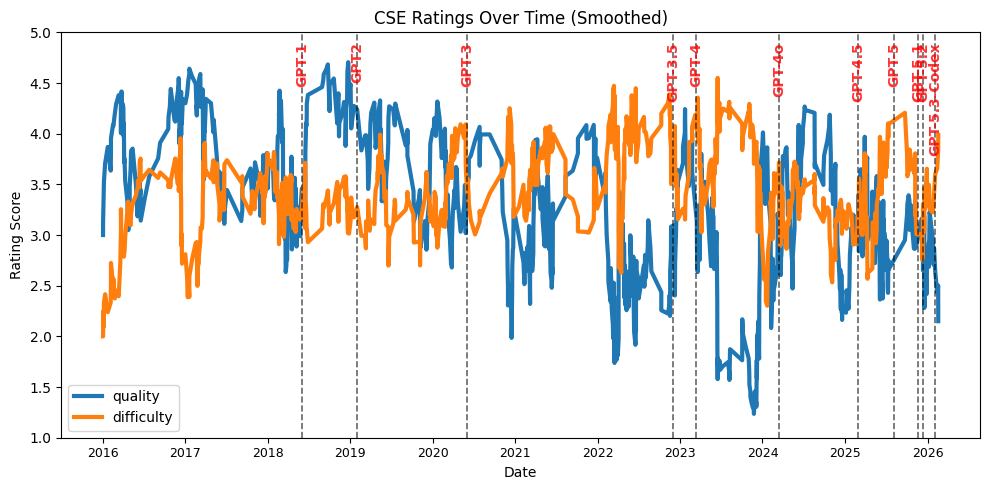

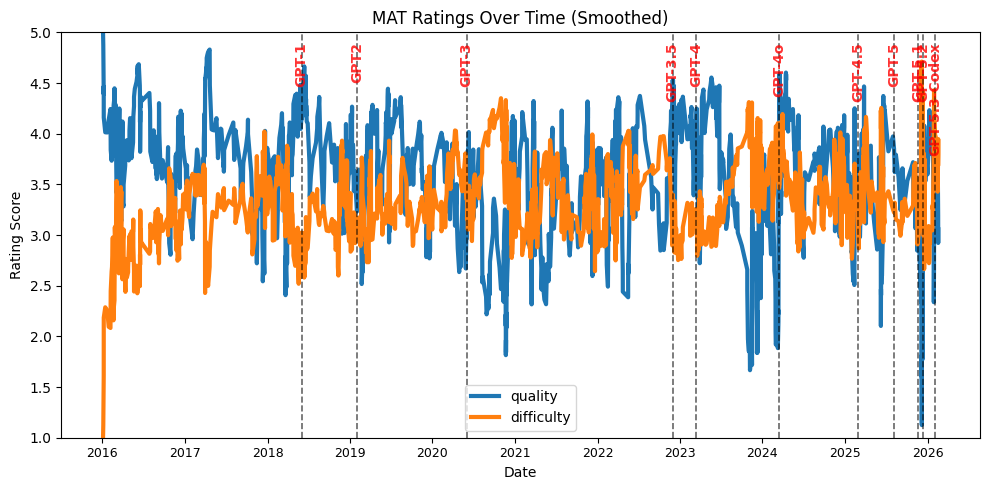

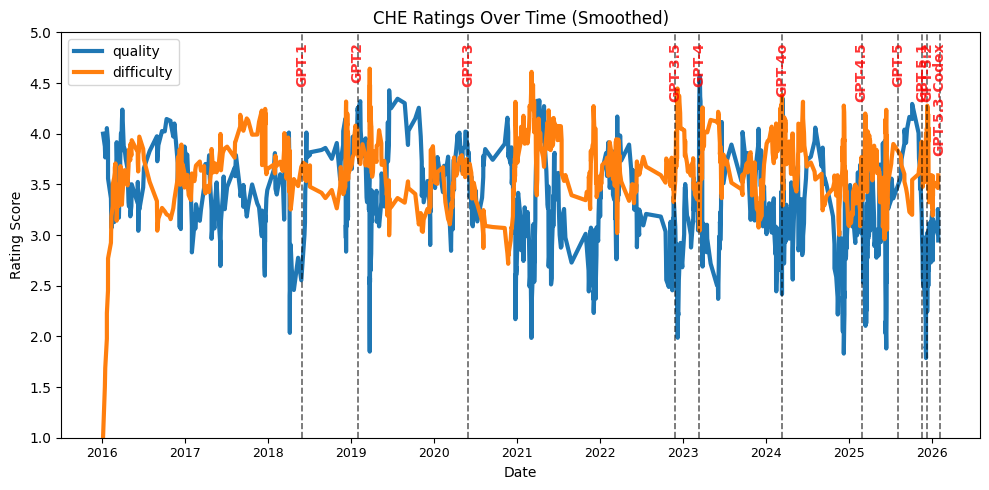

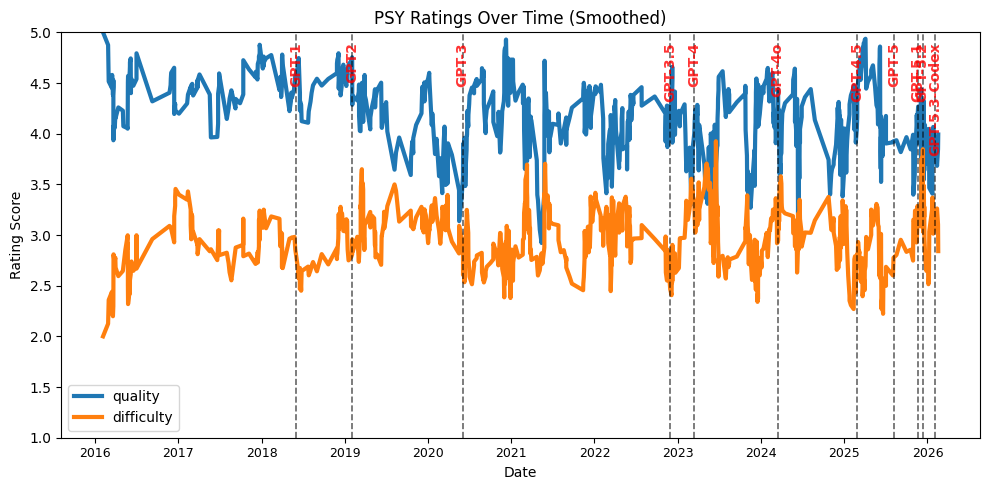

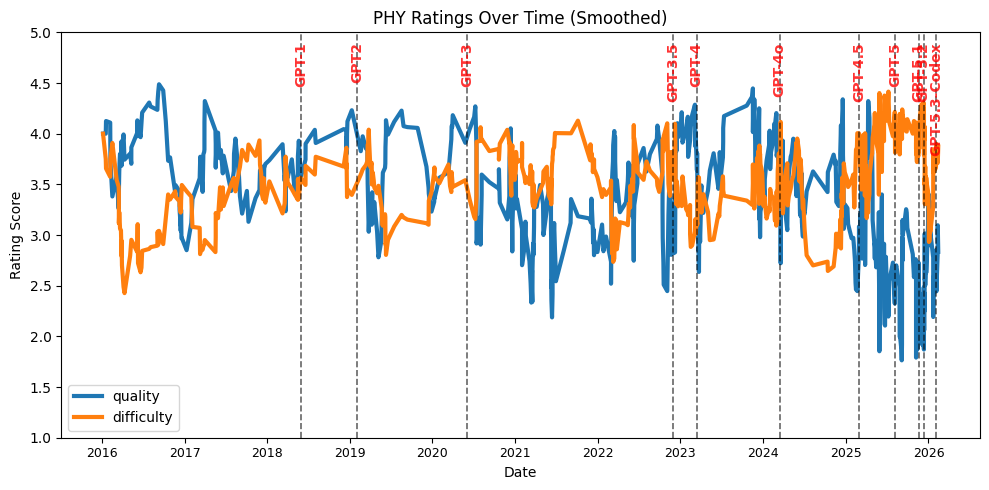

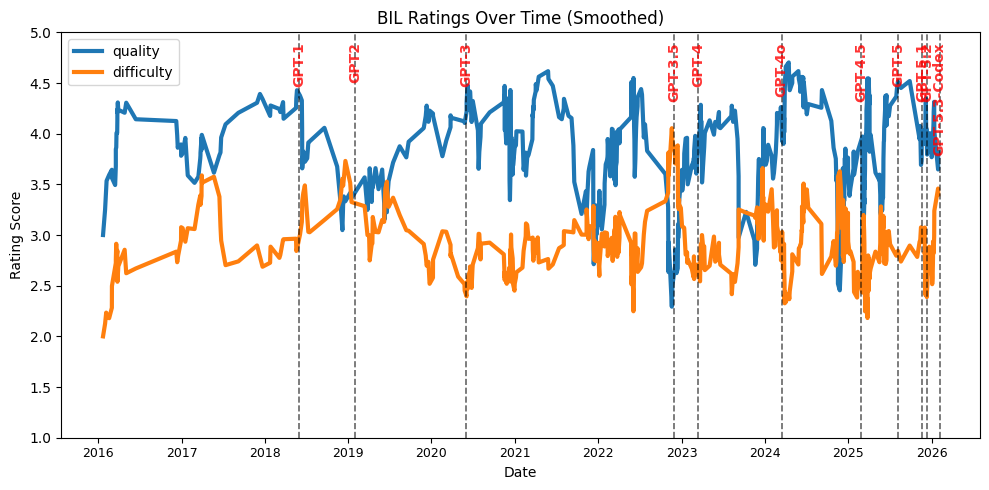

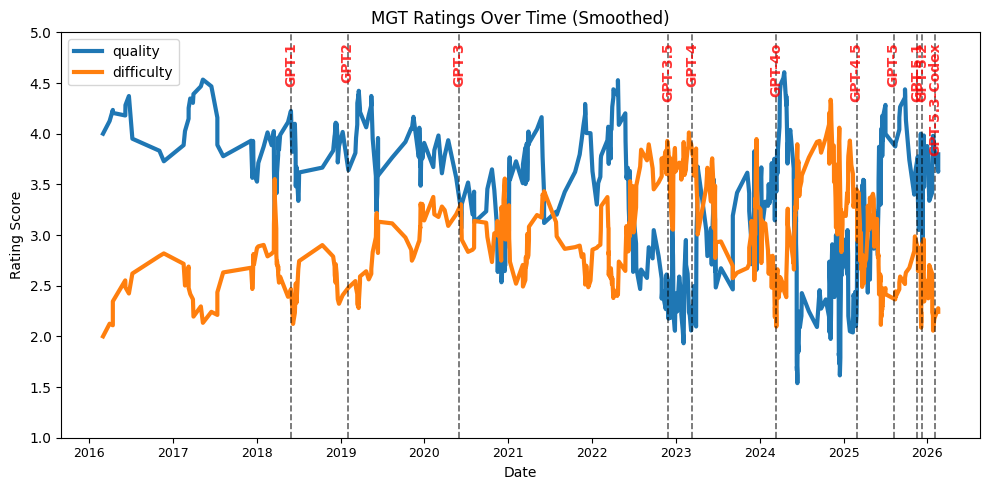

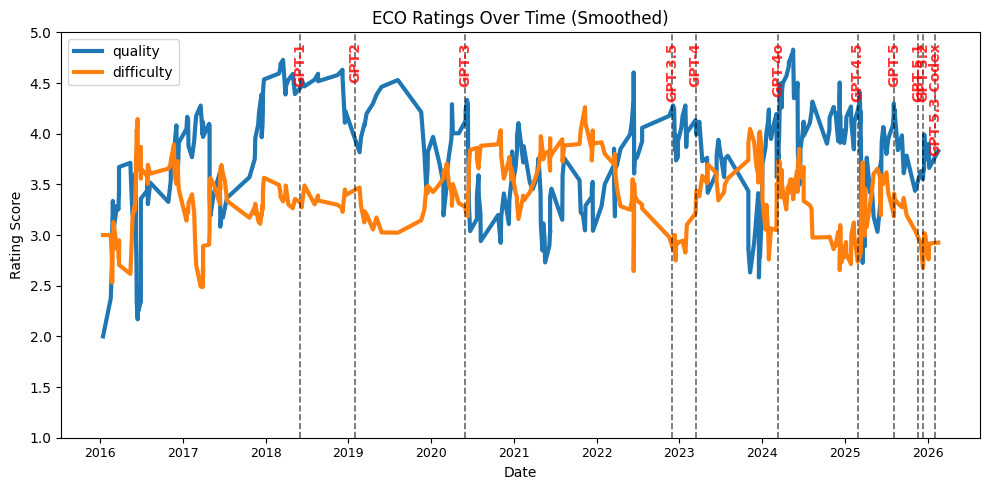

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.243,3.135,37
1,GPT-1 to GPT2,3.500,4.000,6
2,GPT2 to GPT-3,3.875,3.562,16
3,GPT-3 to GPT-3.5,3.484,3.568,95
4,GPT-3.5 to GPT-4,3.786,3.857,14
5,GPT-4 to GPT-4o,2.907,3.977,43
6,GPT-4o to GPT-4.5,3.580,3.340,50
7,GPT-4.5 to GPT-5,3.286,3.857,70
8,GPT-5 to GPT-5.1,4.100,3.300,20
9,GPT-5.1 to GPT-5.2,3.000,2.000,4


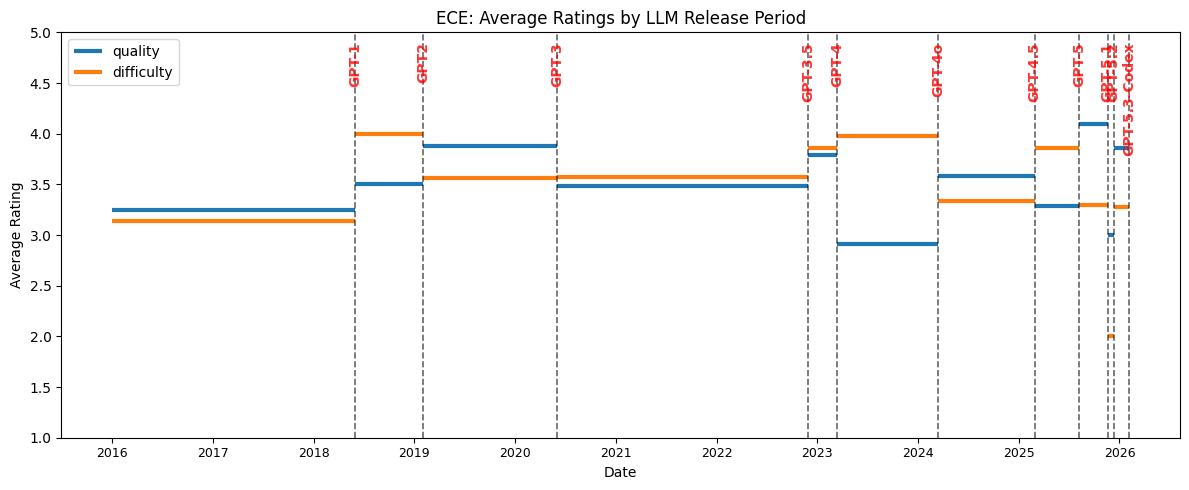

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,4.143,3.476,21
1,GPT-1 to GPT2,4.667,3.667,9
2,GPT2 to GPT-3,3.611,3.389,18
3,GPT-3 to GPT-3.5,4.324,3.324,37
4,GPT-3.5 to GPT-4,5.000,4.000,2
5,GPT-4 to GPT-4o,4.417,3.125,24
6,GPT-4o to GPT-4.5,4.222,2.944,18
7,GPT-4.5 to GPT-5,3.500,2.864,22
8,GPT-5 to GPT-5.1,3.250,2.250,4
9,GPT-5.1 to GPT-5.2,1.000,4.000,1


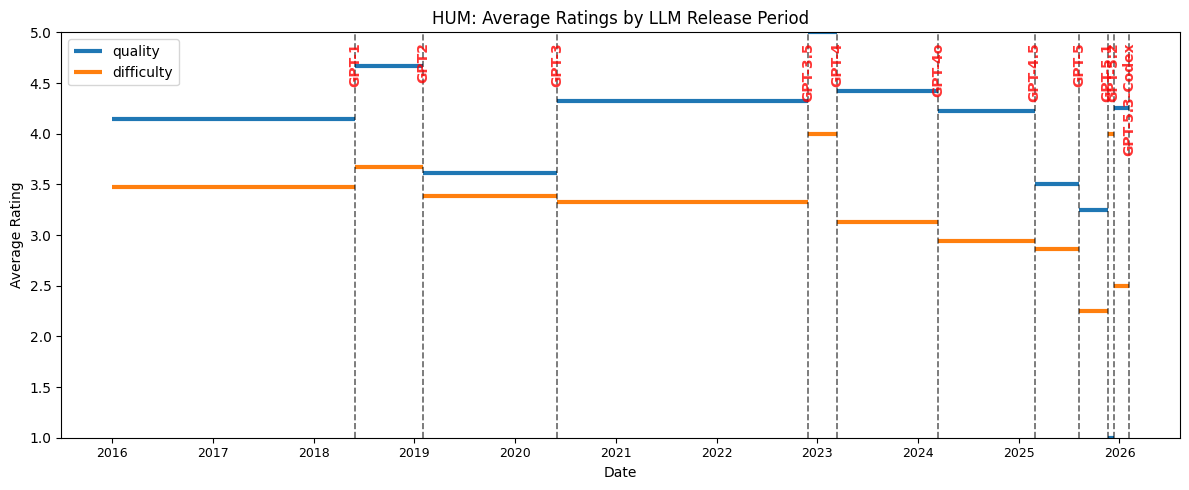

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.790,3.270,233
1,GPT-1 to GPT2,4.302,3.283,53
2,GPT2 to GPT-3,3.590,3.419,105
3,GPT-3 to GPT-3.5,2.808,3.779,213
4,GPT-3.5 to GPT-4,3.500,3.769,26
5,GPT-4 to GPT-4o,2.476,3.621,124
6,GPT-4o to GPT-4.5,3.280,3.215,93
7,GPT-4.5 to GPT-5,3.106,3.506,85
8,GPT-5 to GPT-5.1,3.235,3.176,17
9,GPT-5.1 to GPT-5.2,3.667,2.333,3


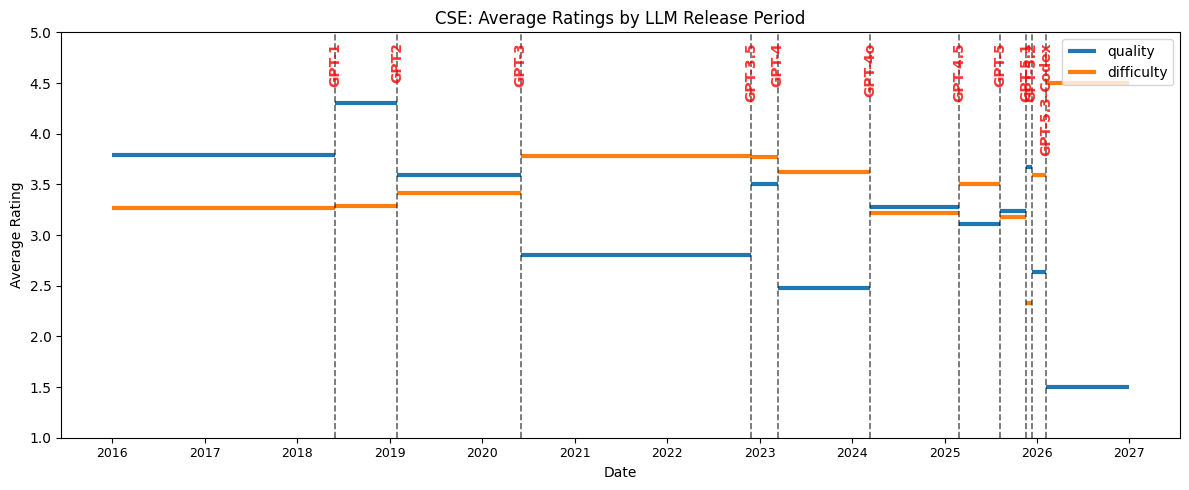

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.752,3.157,415
1,GPT-1 to GPT2,3.672,3.224,125
2,GPT2 to GPT-3,3.533,3.383,227
3,GPT-3 to GPT-3.5,3.458,3.401,548
4,GPT-3.5 to GPT-4,3.950,3.083,60
5,GPT-4 to GPT-4o,3.052,3.576,231
6,GPT-4o to GPT-4.5,3.677,3.428,229
7,GPT-4.5 to GPT-5,3.537,3.537,108
8,GPT-5 to GPT-5.1,3.136,3.227,22
9,GPT-5.1 to GPT-5.2,2.046,4.204,108


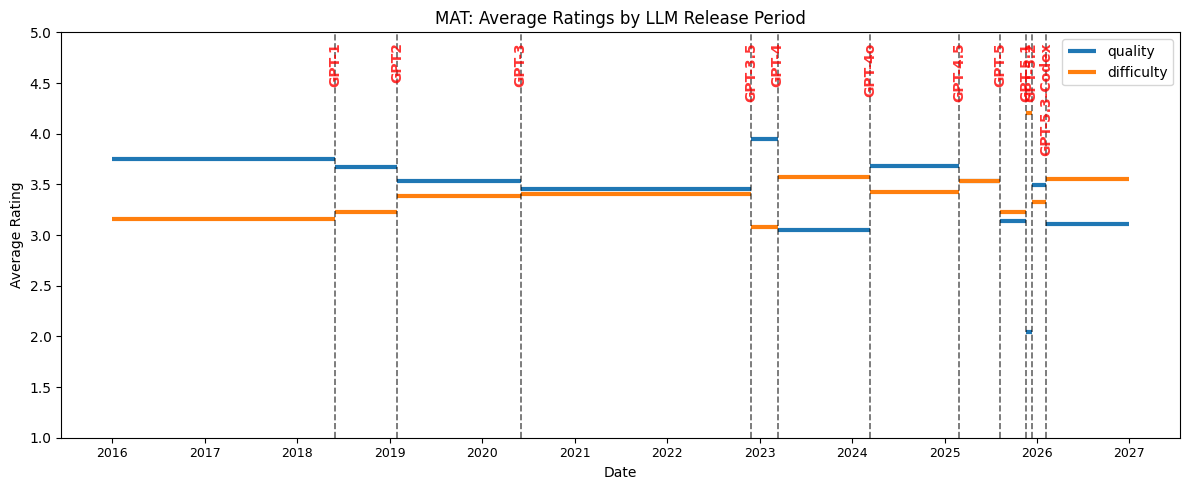

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.370,3.703,192
1,GPT-1 to GPT2,3.754,3.820,61
2,GPT2 to GPT-3,3.466,3.644,146
3,GPT-3 to GPT-3.5,3.209,3.709,296
4,GPT-3.5 to GPT-4,2.980,3.837,49
5,GPT-4 to GPT-4o,3.380,3.754,142
6,GPT-4o to GPT-4.5,3.063,3.648,159
7,GPT-4.5 to GPT-5,3.051,3.688,157
8,GPT-5 to GPT-5.1,3.833,3.556,18
9,GPT-5.1 to GPT-5.2,2.190,3.857,21


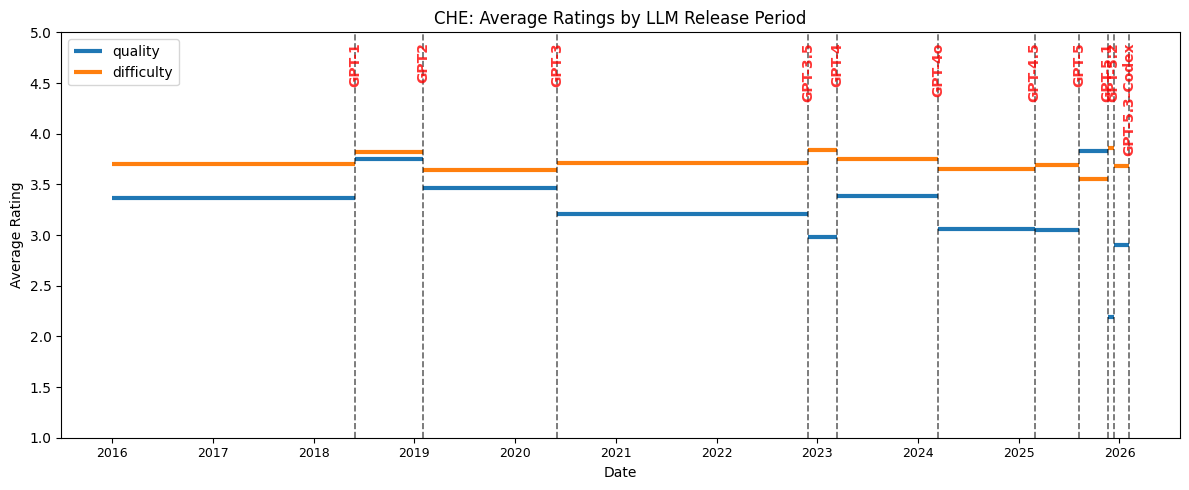

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,4.448,2.909,143
1,GPT-1 to GPT2,4.550,2.850,40
2,GPT2 to GPT-3,4.031,3.134,97
3,GPT-3 to GPT-3.5,4.218,2.926,284
4,GPT-3.5 to GPT-4,4.000,3.133,30
5,GPT-4 to GPT-4o,3.964,3.050,139
6,GPT-4o to GPT-4.5,4.000,2.975,122
7,GPT-4.5 to GPT-5,4.352,2.718,71
8,GPT-5 to GPT-5.1,4.000,3.176,17
9,GPT-5.1 to GPT-5.2,3.694,3.472,36


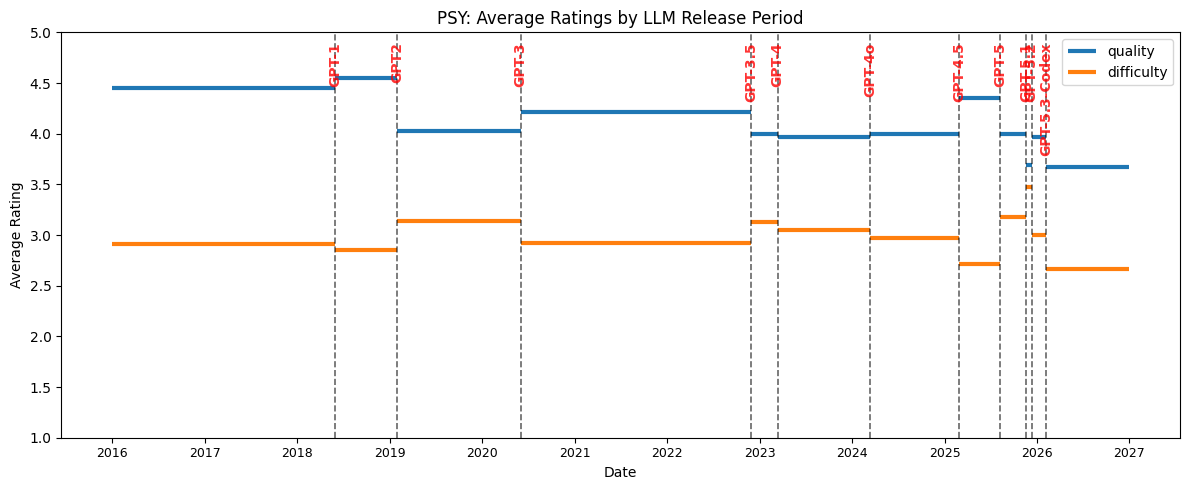

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.675,3.219,114
1,GPT-1 to GPT2,4.267,3.533,15
2,GPT2 to GPT-3,3.553,3.447,47
3,GPT-3 to GPT-3.5,3.154,3.586,162
4,GPT-3.5 to GPT-4,3.889,3.361,36
5,GPT-4 to GPT-4o,3.635,3.486,74
6,GPT-4o to GPT-4.5,3.345,3.440,84
7,GPT-4.5 to GPT-5,3.019,3.837,104
8,GPT-5 to GPT-5.1,2.435,3.978,46
9,GPT-5.1 to GPT-5.2,1.846,4.385,13


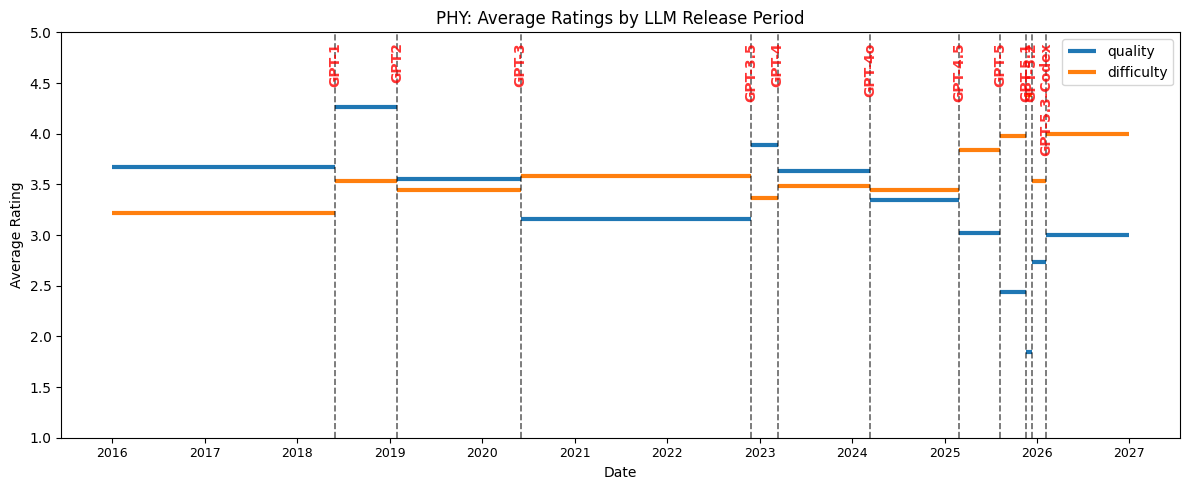

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,4.119,2.966,59
1,GPT-1 to GPT2,3.278,3.500,18
2,GPT2 to GPT-3,3.914,2.800,35
3,GPT-3 to GPT-3.5,3.782,2.927,179
4,GPT-3.5 to GPT-4,3.750,2.786,28
5,GPT-4 to GPT-4o,3.831,3.028,71
6,GPT-4o to GPT-4.5,3.804,2.928,97
7,GPT-4.5 to GPT-5,3.946,2.770,74
8,GPT-5 to GPT-5.1,3.500,3.000,8
9,GPT-5.1 to GPT-5.2,4.077,2.385,13


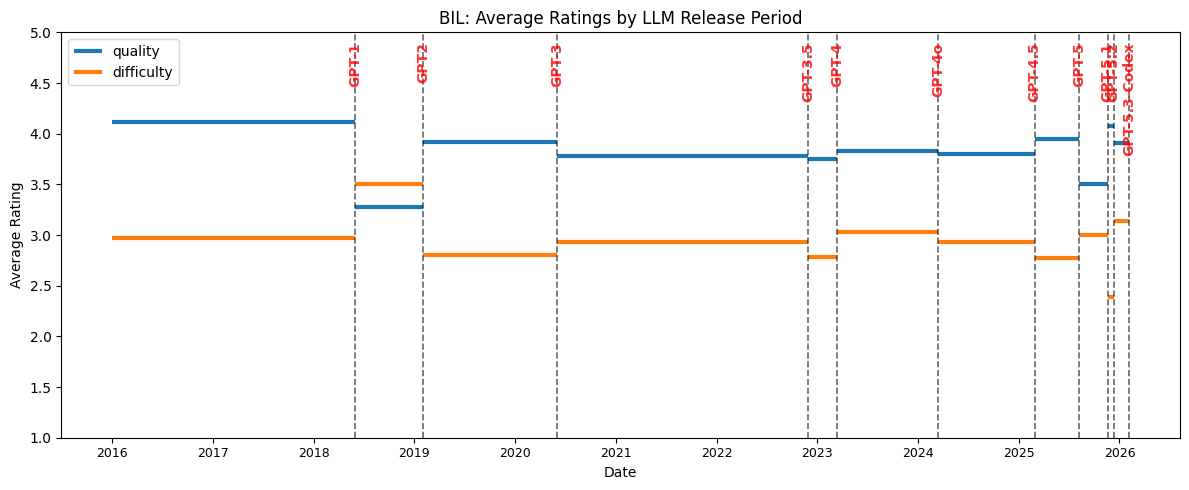

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.961,2.686,51
1,GPT-1 to GPT2,3.750,2.500,20
2,GPT2 to GPT-3,3.816,3.000,49
3,GPT-3 to GPT-3.5,3.344,3.069,131
4,GPT-3.5 to GPT-4,2.353,3.588,34
5,GPT-4 to GPT-4o,3.227,2.989,88
6,GPT-4o to GPT-4.5,2.648,3.424,125
7,GPT-4.5 to GPT-5,3.421,2.711,76
8,GPT-5 to GPT-5.1,3.750,2.917,12
9,GPT-5.1 to GPT-5.2,3.353,2.412,17


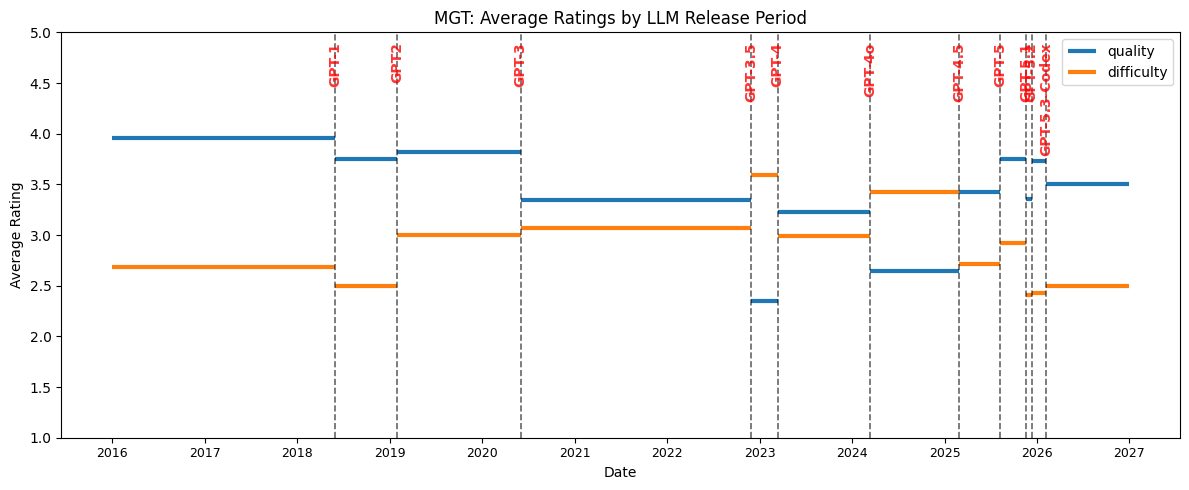

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.765,3.343,102
1,GPT-1 to GPT2,4.364,3.364,11
2,GPT2 to GPT-3,3.889,3.333,27
3,GPT-3 to GPT-3.5,3.579,3.579,95
4,GPT-3.5 to GPT-4,4.000,3.077,13
5,GPT-4 to GPT-4o,3.463,3.585,41
6,GPT-4o to GPT-4.5,4.242,3.212,66
7,GPT-4.5 to GPT-5,3.577,3.327,52
8,GPT-5 to GPT-5.1,3.000,2.833,6
9,GPT-5.1 to GPT-5.2,5.000,2.000,1


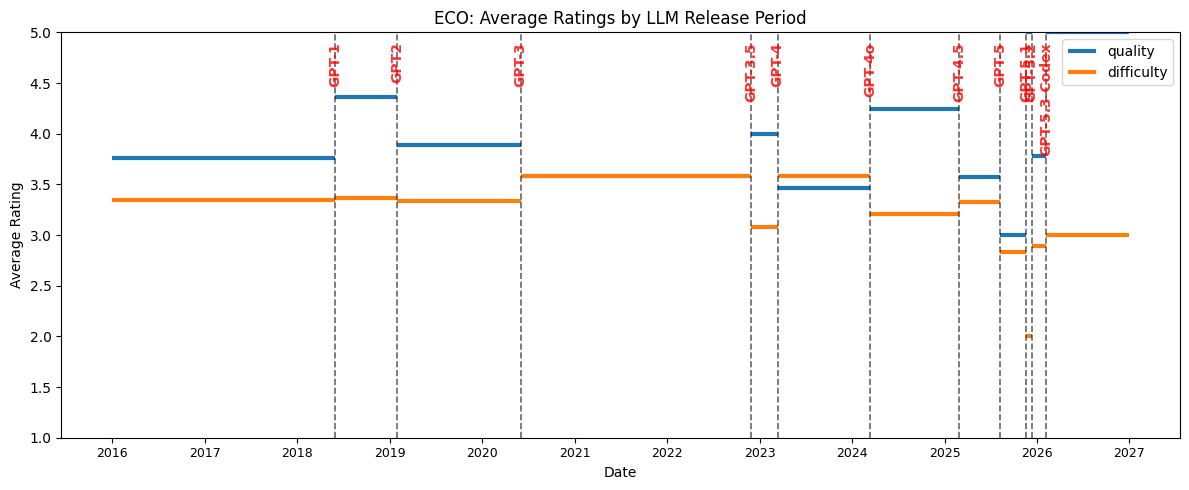

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.788,3.225,1367
1,GPT-1 to GPT2,3.930,3.307,358
2,GPT2 to GPT-3,3.649,3.361,767
3,GPT-3 to GPT-3.5,3.479,3.386,2040
4,GPT-3.5 to GPT-4,3.541,3.384,292
5,GPT-4 to GPT-4o,3.317,3.440,977
6,GPT-4o to GPT-4.5,3.488,3.317,1043
7,GPT-4.5 to GPT-5,3.410,3.380,819
8,GPT-5 to GPT-5.1,3.288,3.394,170
9,GPT-5.1 to GPT-5.2,2.594,3.733,217


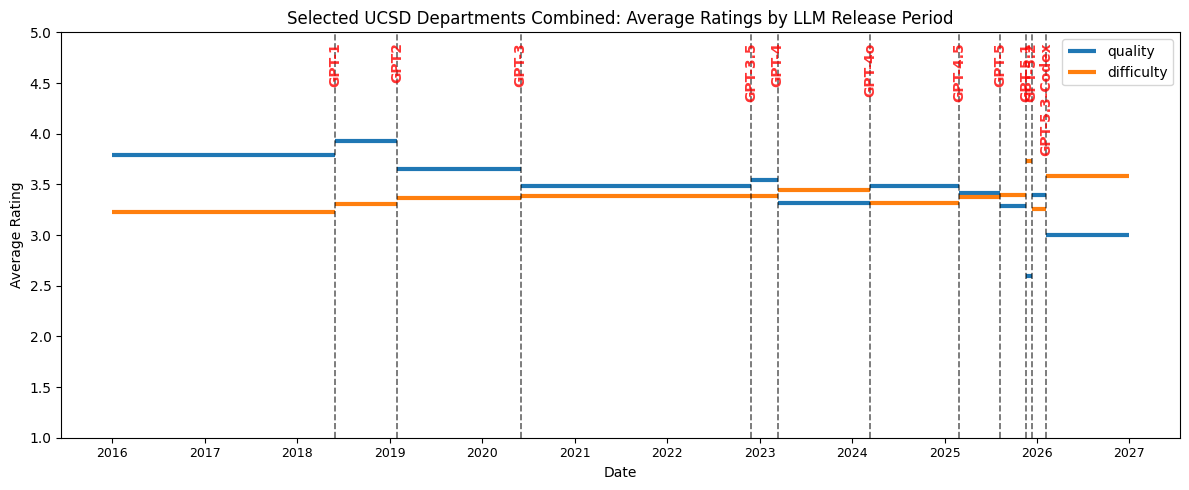

In [4]:
departments = major_departments(
    reviews_df,
    include=["ECE", "HUM", "CSE", "MATH"],
    top_n=8,
)

department_reviews, department_trends = prepare_department_analysis(
    df=reviews_df,
    departments=departments,
    start_date=analysis_start,
    end_date=analysis_end,
)

for department in departments:
    fig, ax = plot_department_ratings(department_trends, department)
    overlay_releases(ax, releases_df)
    plt.show()

for department in departments:
    department_release_summary = summarize_release_period_ratings(
        department_reviews.loc[department_reviews["department"] == department],
        releases_df=releases_df,
    )
    display(
        department_release_summary[[
            "release_period",
            "quality_mean",
            "difficulty_mean",
            "review_count",
        ]].round(3)
    )

    fig, ax = plot_release_period_ratings(
        department_release_summary,
        releases_df=releases_df,
        title=f"{department}: Average Ratings by LLM Release Period",
        start_date=analysis_start,
        end_date=analysis_end,
    )
    overlay_releases(ax, releases_df)
    plt.show()

selected_departments_release_summary = summarize_release_period_ratings(
    department_reviews,
    releases_df=releases_df,
)
display(
    selected_departments_release_summary[[
        "release_period",
        "quality_mean",
        "difficulty_mean",
        "review_count",
    ]].round(3)
)

fig, ax = plot_release_period_ratings(
    selected_departments_release_summary,
    releases_df=releases_df,
    title="Selected UCSD Departments Combined: Average Ratings by LLM Release Period",
    start_date=analysis_start,
    end_date=analysis_end,
)
overlay_releases(ax, releases_df)
plt.show()


## Department Release Behavior

In [5]:
department_behavior_summary = summarize_department_release_behaviors(
    df=reviews_df,
    releases_df=releases_df,
    start_date=classification_start,
    end_date=classification_end,
    stable_threshold=0.15,
)
display(department_behavior_summary.round(3))

department_behavior_counts = count_department_release_behaviors(
    department_behavior_summary
)
display(department_behavior_counts)


,department,release_period_count,review_count,first_release_period,last_release_period,quality_delta,difficulty_delta,behavior
0,MAT,6,594,GPT-4 to GPT-4o,GPT-5.2 to GPT-5.3-Codex,0.661,-0.502,improving
1,ECE,6,176,GPT-4 to GPT-4o,GPT-5.2 to GPT-5.3-Codex,0.433,-0.891,improving
2,MMW,6,152,GPT-4 to GPT-4o,GPT-5.2 to GPT-5.3-Codex,0.706,-0.275,improving
3,VIS,6,126,GPT-4 to GPT-4o,GPT-5.2 to GPT-5.3-Codex,1.333,-1.212,improving
4,POL,6,114,GPT-4 to GPT-4o,GPT-5.2 to GPT-5.3-Codex,2.067,-0.200,improving
...,...,...,...,...,...,...,...,...
81,LIT,3,3,GPT-4o to GPT-4.5,GPT-5 to GPT-5.1,1.000,0.000,stable
82,SEO,2,3,GPT-4.5 to GPT-5,GPT-5 to GPT-5.1,0.000,0.500,stable
83,ENG,2,2,GPT-4 to GPT-4o,GPT-4o to GPT-4.5,0.000,3.000,stable
84,LIS,2,2,GPT-4o to GPT-4.5,GPT-4.5 to GPT-5,0.000,1.000,stable


,behavior,department_count
0,inverting,21
1,stable,40
2,improving,25


## Overall Review Trends

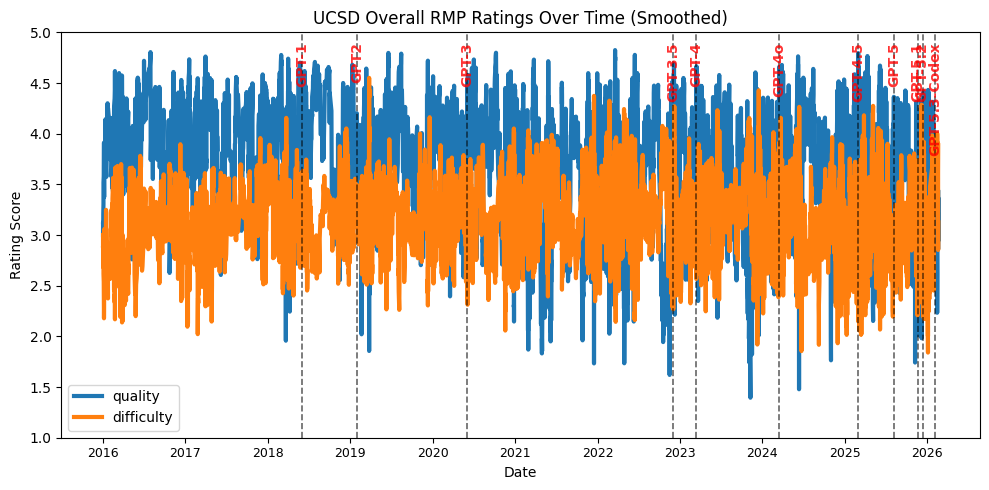

,release_period,quality_mean,difficulty_mean,review_count
0,Pre-GPT-1,3.856,3.091,2245
1,GPT-1 to GPT2,3.869,3.226,597
2,GPT2 to GPT-3,3.781,3.185,1490
3,GPT-3 to GPT-3.5,3.575,3.208,3618
4,GPT-3.5 to GPT-4,3.639,3.101,504
5,GPT-4 to GPT-4o,3.485,3.182,1786
6,GPT-4o to GPT-4.5,3.668,3.038,2126
7,GPT-4.5 to GPT-5,3.663,3.009,1592
8,GPT-5 to GPT-5.1,3.454,3.086,280
9,GPT-5.1 to GPT-5.2,3.127,3.220,387


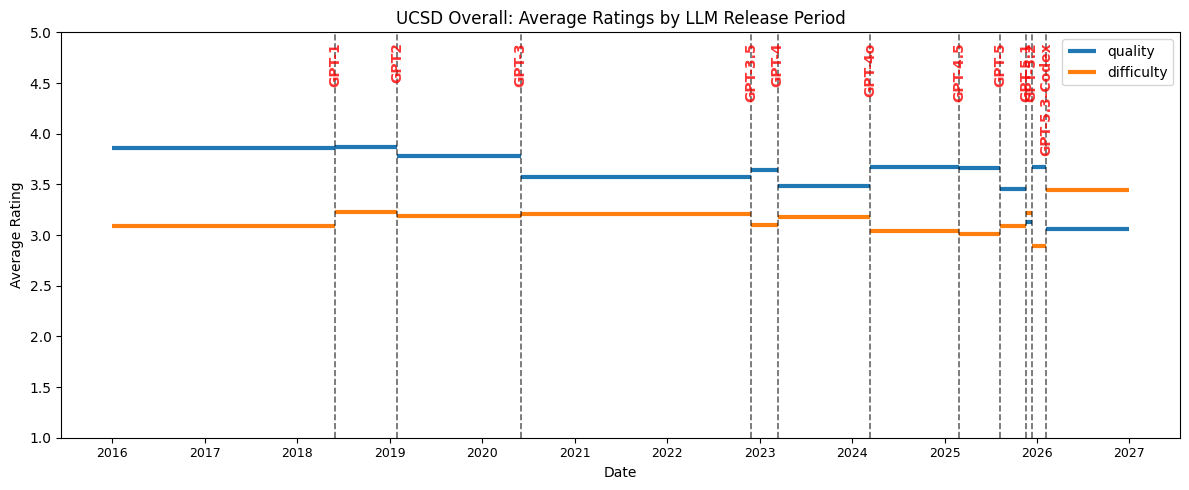

In [6]:
overall_reviews, overall_trends = prepare_overall_analysis(
    reviews_df,
    start_date=analysis_start,
    end_date=analysis_end,
)

fig, ax = plot_overall_ratings(
    overall_trends,
    title="UCSD Overall RMP Ratings Over Time (Smoothed)",
)
overlay_releases(ax, releases_df)
plt.show()

overall_release_summary = summarize_release_period_ratings(
    overall_reviews,
    releases_df=releases_df,
)
display(
    overall_release_summary[[
        "release_period",
        "quality_mean",
        "difficulty_mean",
        "review_count",
    ]].round(3)
)

fig, ax = plot_release_period_ratings(
    overall_release_summary,
    releases_df=releases_df,
    title="UCSD Overall: Average Ratings by LLM Release Period",
    start_date=analysis_start,
    end_date=analysis_end,
)
overlay_releases(ax, releases_df)
plt.show()


## Course Trends

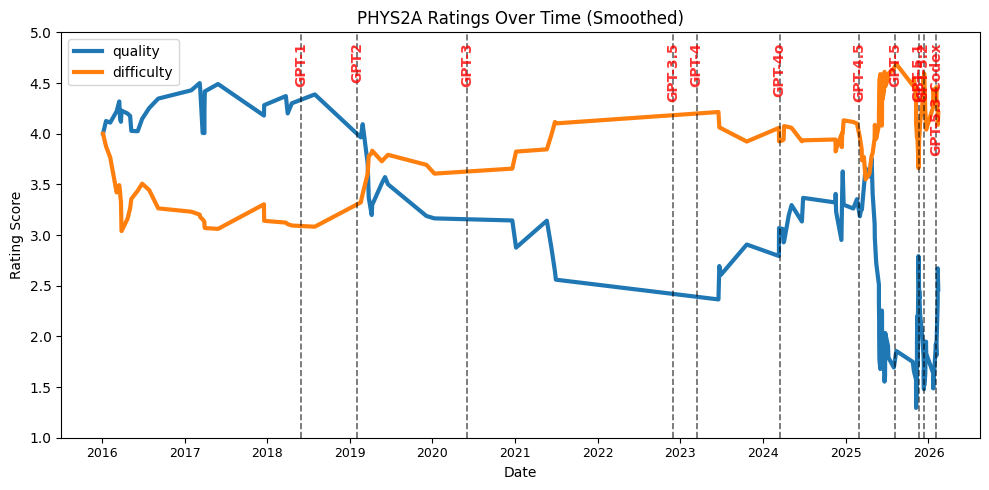

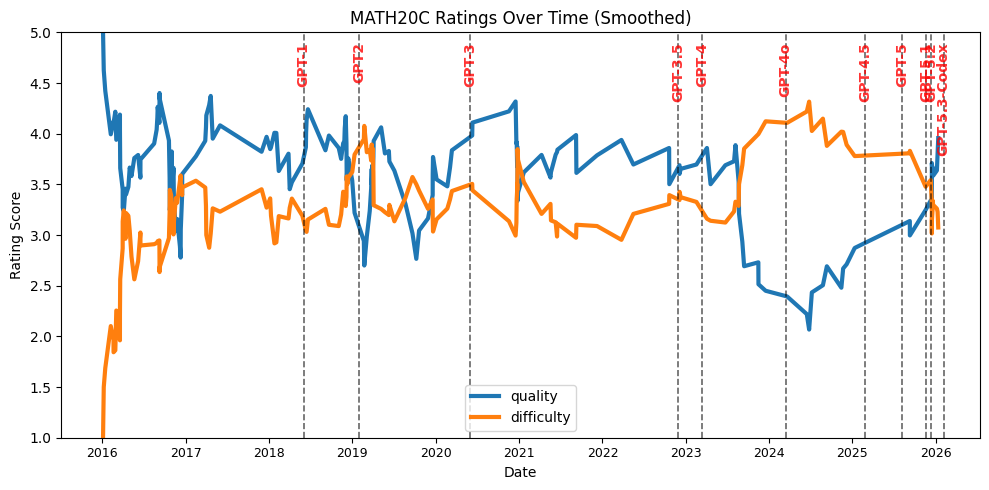

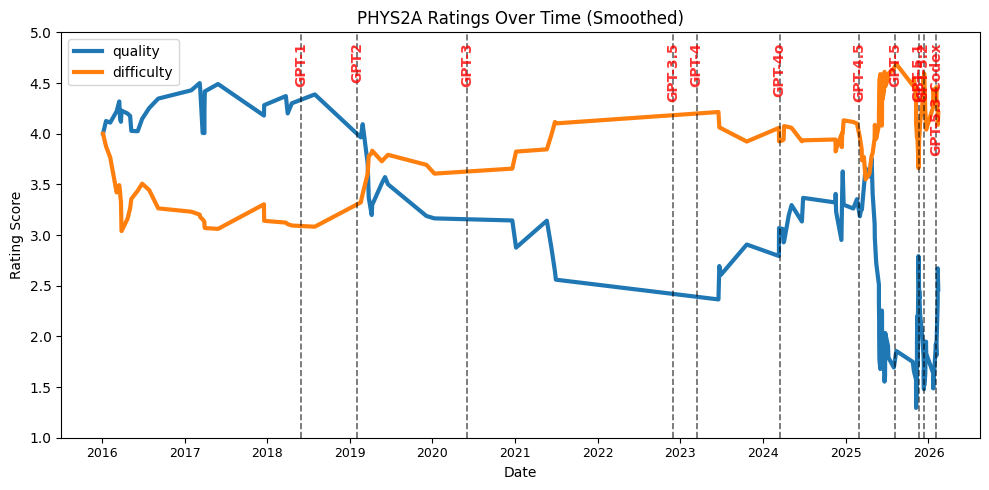

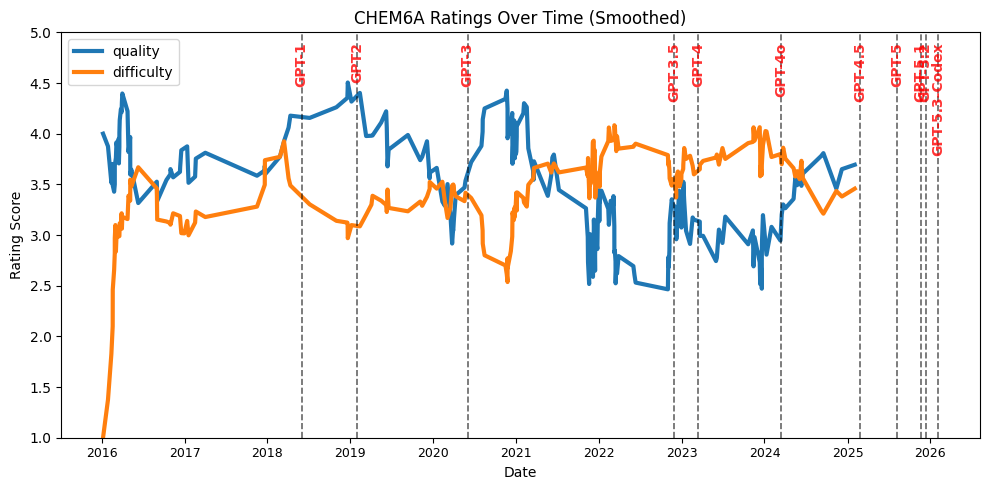

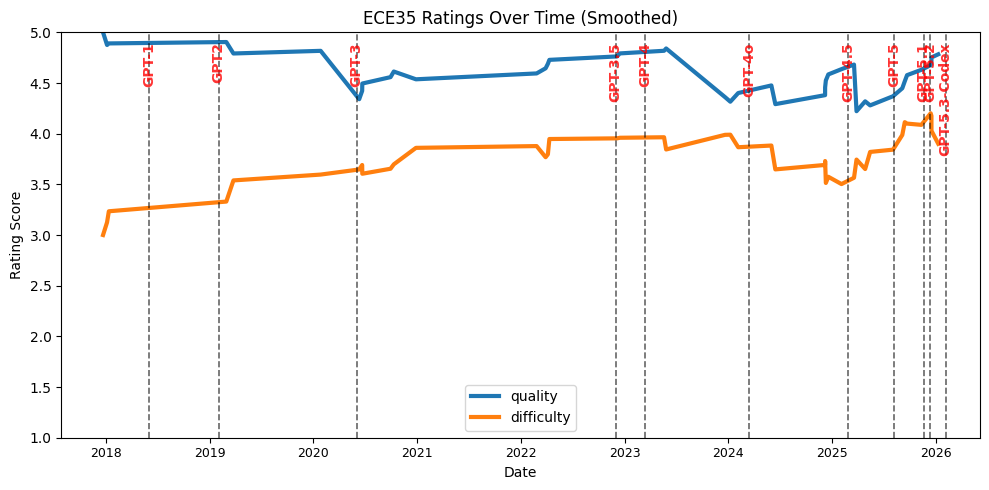

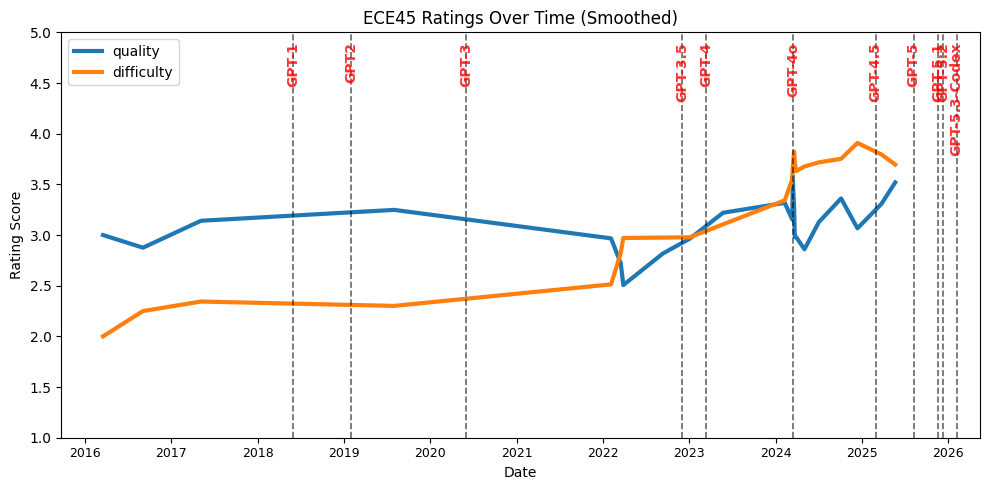

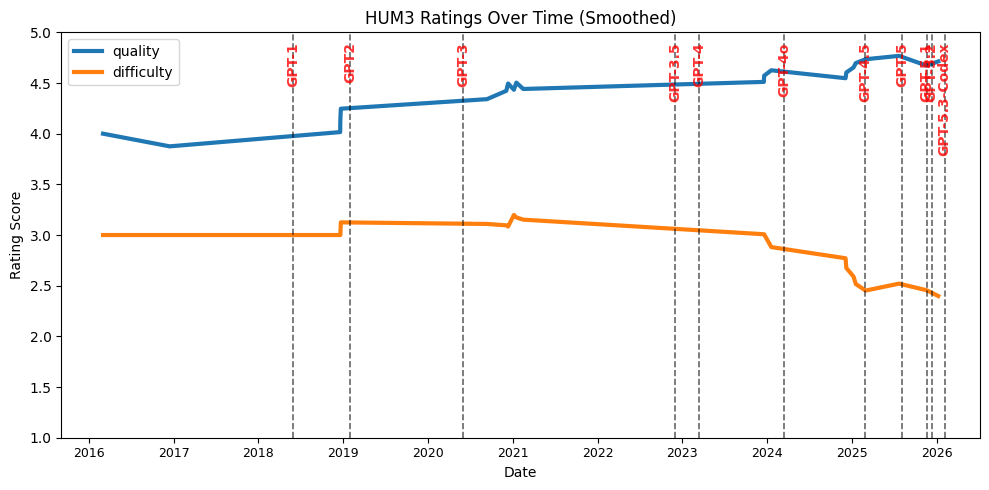

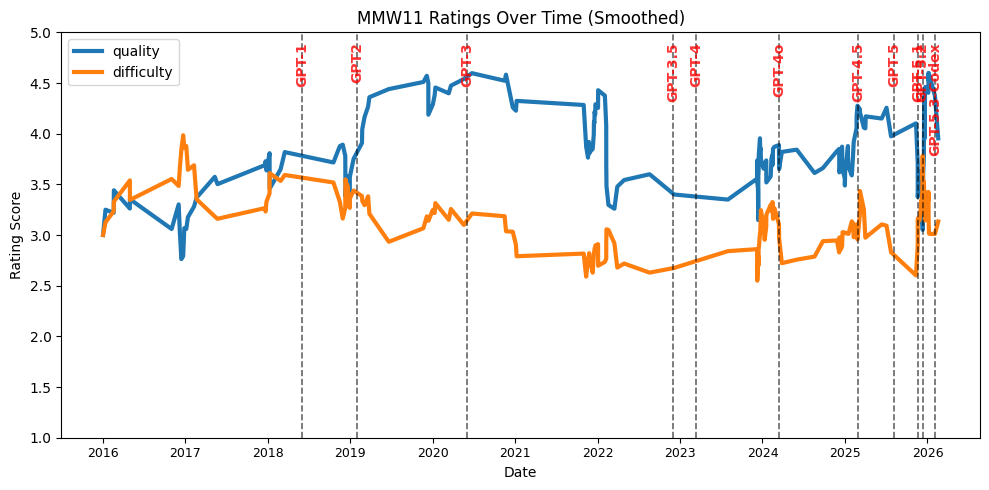

In [7]:
course_reviews, course_trends = prepare_course_analysis(
    reviews_df,
    course=selected_course,
    start_date=analysis_start,
    end_date=analysis_end,
)

fig, ax = plot_smoothed_ratings(course_trends, selected_course)
overlay_releases(ax, releases_df)
plt.show()

for course in course_list:
    _, smoothed_course = prepare_course_analysis(
        reviews_df,
        course=course,
        start_date=analysis_start,
        end_date=analysis_end,
    )
    fig, ax = plot_smoothed_ratings(smoothed_course, course)
    overlay_releases(ax, releases_df)
    plt.show()
